In [31]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import random

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [33]:
df = pd.read_csv('mountains_vs_beaches_preferences.csv')
df

,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,male,71477,bachelor,9,skiing,2477,urban,175,267,summer,0,1,1
1,69,male,88740,master,1,swimming,4777,suburban,228,190,fall,0,1,0
2,46,female,46562,master,0,skiing,1469,urban,71,280,winter,0,0,1
3,32,non-binary,99044,high school,6,hiking,1482,rural,31,255,summer,1,0,1
4,60,female,106583,high school,5,sunbathing,516,suburban,23,151,winter,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52439,67,female,85325,master,3,hiking,1762,suburban,51,262,fall,1,0,1
52440,37,female,110346,bachelor,7,swimming,1676,urban,259,84,spring,1,0,0
52441,53,non-binary,71080,doctorate,7,swimming,3877,urban,164,27,fall,0,1,0
52442,40,female,75174,doctorate,9,swimming,4620,suburban,173,10,summer,0,1,0


In [37]:
import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning)
wrn.filterwarnings('ignore', category = FutureWarning)
wrn.filterwarnings('ignore', category = UserWarning)
df["Gender"].replace(to_replace = ['non-binary', 'male', 'female'], value = [0, 1, 2], inplace = True)
df["Education_Level"].replace(to_replace = ['high school', 'bachelor', 'master', 'doctorate'], value = [0, 1, 2, 3], inplace = True)
df["Preferred_Activities"].replace(to_replace = ['sunbathing', 'swimming', 'hiking', 'skiing'], value = [0, 1, 2, 3], inplace = True)
df["Location"].replace(to_replace = ['urban', 'suburban', 'rural'], value = [0, 1, 2], inplace = True)
df["Favorite_Season"].replace(to_replace = ['spring', 'summer', 'fall', 'winter'], value = [0, 1, 2, 3], inplace = True)
df[["Gender", "Education_Level", "Preferred_Activities", "Location", "Favorite_Season"]] = df[["Gender", "Education_Level", "Preferred_Activities", "Location", "Favorite_Season"]].apply(pd.to_numeric)
df.head(10)

,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,1,71477,1,9,3,2477,0,175,267,1,0,1,1
1,69,1,88740,2,1,1,4777,1,228,190,2,0,1,0
2,46,2,46562,2,0,3,1469,0,71,280,3,0,0,1
3,32,0,99044,0,6,2,1482,2,31,255,1,1,0,1
4,60,2,106583,0,5,0,516,1,23,151,3,1,1,0
5,25,1,110588,3,3,0,2895,0,6,47,2,0,1,0
6,38,1,22245,1,1,1,4994,2,157,225,2,0,1,0
7,56,0,109411,1,8,0,3656,0,210,166,3,1,0,0
8,36,1,22531,2,6,1,2408,1,218,263,1,1,1,0
9,40,0,90840,0,1,1,4044,2,271,15,1,1,1,0


In [45]:
y = df[['Preference']]
X = df[['Age', 'Gender', 'Income', 'Education_Level', 'Travel_Frequency', 'Preferred_Activities', 'Vacation_Budget', 'Location', 'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Favorite_Season', 'Pets', 'Environmental_Concerns']]

In [65]:
y_n = y.to_numpy().T[0]

In [67]:
X_n = X.to_numpy()

In [69]:
from sklearn.datasets import load_wine
wine = load_wine()
X = wine['data']
y = wine['target']
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [71]:
num_input_feat = X_n.shape[1]
print('num_of_samples: ', X_n.shape[0])
print('num_input_feat: ', num_input_feat)
num_outputs = 2
print('num_outputs', num_outputs)

scaler = StandardScaler()
X_n = scaler.fit_transform(X_n)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X_n, y_n, test_size=0.2, random_state=42)

num_of_samples:  52444
num_input_feat:  13
num_outputs 2


In [73]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [75]:
# Створюємо TensorDataset
train_data = TensorDataset(X_train, y_train)
test_data  = TensorDataset(X_test, y_test)

# Створюємо DataLoader-и
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

In [77]:
for xb, yb in train_loader:
    print(xb.shape, yb.shape)
    break

torch.Size([32, 13]) torch.Size([32])


In [79]:
class VacMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_input_feat, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, num_outputs)   # logits для 2 класів
        )

    def forward(self, x):
        logits = self.net(x)
        return logits

model = VacMLP().to(device)
print(model)

VacMLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [81]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

net.0.weight 832
net.0.bias 64
net.2.weight 2048
net.2.bias 32
net.4.weight 64
net.4.bias 2


In [83]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [85]:
n_epochs = 15

In [87]:
train_loss_history = []
val_loss_history = []
for epoch in range(n_epochs):

    # --- train ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

[01] train_loss=0.0986 | val_loss=0.0261
[02] train_loss=0.0164 | val_loss=0.0143
[03] train_loss=0.0118 | val_loss=0.0129
[04] train_loss=0.0103 | val_loss=0.0109
[05] train_loss=0.0091 | val_loss=0.0092
[06] train_loss=0.0085 | val_loss=0.0086
[07] train_loss=0.0081 | val_loss=0.0106
[08] train_loss=0.0071 | val_loss=0.0117
[09] train_loss=0.0066 | val_loss=0.0092
[10] train_loss=0.0070 | val_loss=0.0105
[11] train_loss=0.0067 | val_loss=0.0114
[12] train_loss=0.0057 | val_loss=0.0084
[13] train_loss=0.0072 | val_loss=0.0155
[14] train_loss=0.0056 | val_loss=0.0112
[15] train_loss=0.0052 | val_loss=0.0120


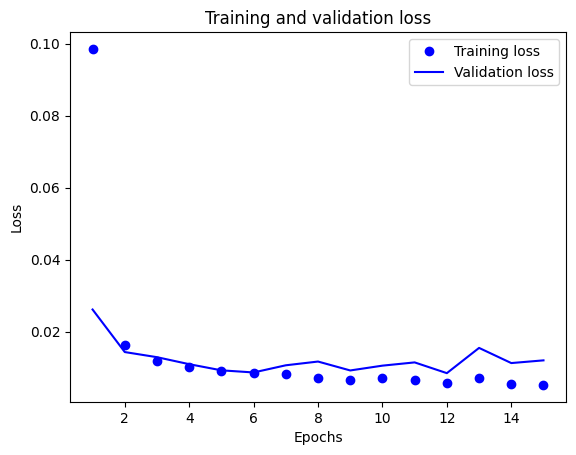

In [89]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [91]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Final Test Accuracy: {correct/total*100:.2f}%")

Final Test Accuracy: 99.50%
